# Seurat Wrapper + Circos Visualization

In this notebook, you can learn how to visualize the output of a NicheNet analysis in a circos plot (chord diagram). This follows the same workflow as the wrapper notebook, then adds circos visualizations.

Note that we generally recommend combining heatmaps (ligand activity, ligand-target, ligand-receptor, expression, LFC) over circos plots, especially when many sender cell types are involved. Circos plots can be less informative and lead to wrong interpretation in complex cases.

We again use NICHE-seq data from Medaglia et al. (2017).

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import nichenetr as nn

In [2]:
sns.set_style('ticks')

### Load data and networks

In [3]:
ligand_target_matrix = nn.load_ligand_target_matrix("mouse")
lr_network = nn.load_lr_network("mouse")
weighted_networks = nn.load_weighted_networks("mouse")

lr_network = lr_network[["from", "to"]].drop_duplicates()

adata = nn.load_seurat_obj()
adata = nn.alias_to_symbol_anndata(adata, "mouse")

In [4]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## Perform the NicheNet analysis

We use the top 20 ligands to avoid overcrowding the circos plot.

In [5]:
sender_celltypes = ["CD4 T", "Treg", "Mono", "NK", "B", "DC"]

nichenet_output = nn.nichenet_seuratobj_aggregate(
    receiver="CD8 T",
    adata=adata,
    condition_col="aggregate",
    condition_oi="LCMV",
    condition_ref="SS",
    sender=sender_celltypes,
    celltype_col="celltype",
    ligand_target_matrix=ligand_target_matrix,
    lr_network=lr_network,
    weighted_networks=weighted_networks,
    top_n_ligands=20,
)

Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Perform DE analysis in sender cells


In [6]:
nichenet_output["ligand_activities"]

,test_ligand,auroc,aupr,aupr_corrected,pearson,rank
21,Ebi3,0.634912,0.359367,0.211530,0.264509,1.0
59,Ptprc,0.622791,0.285205,0.137368,0.144479,2.0
36,H2-M3,0.586123,0.254817,0.106981,0.126943,3.0
35,H2-M2,0.587450,0.252966,0.105129,0.120731,5.0
41,H2-T22,0.587450,0.252966,0.105129,0.120731,5.0
...,...,...,...,...,...,...
6,Calr,0.543070,0.175991,0.028154,-0.013061,69.0
53,Mia,0.505976,0.172827,0.024990,0.020214,70.0
56,Nlgn3,0.545008,0.170607,0.022770,-0.015138,71.0
54,Mif,0.549850,0.169827,0.021990,-0.017223,72.0


In [7]:
# Ligand-target heatmap
nichenet_output["ligand_target_heatmap"]
plt.show()

## Circos Plots to Visualize Ligand-Target and Ligand-Receptor Interactions

### Assign ligands to sender cells

We assign each top ligand to the sender cell type where it is most highly expressed.

In [8]:
ligand_type_indication_df = nn.assign_ligands_to_celltype(
    adata,
    celltype_col="celltype",
    sender_celltypes=sender_celltypes,
    ligands_oi=nichenet_output["top_ligands"],
)

print(ligand_type_indication_df.head(10))
print("\nLigand type distribution:")
print(ligand_type_indication_df["ligand_type"].value_counts())

  ligand_type  ligand
0        Mono    Ebi3
1        Mono   Ptprc
2        Mono  H2-T22
3        Mono   Sirpa
4        Mono     App
5        Mono  Cxcl10
6        Mono   Tgfb1
7           B   H2-M3
8          DC   H2-M2
9          DC  H2-T23

Ligand type distribution:
ligand_type
DC         9
Mono       7
NK         2
B          1
General    1
Name: count, dtype: int64


### Define the ligand-target links of interest

We show only links with a weight higher than a predefined cutoff (bottom 40% of scores removed).

In [9]:
active_ligand_target_links_df = nichenet_output["ligand_target_df"].copy()
active_ligand_target_links_df["target_type"] = "LCMV-DE"

circos_links = nn.get_ligand_target_links_oi(
    ligand_type_indication_df,
    active_ligand_target_links_df,
    cutoff=0.40,
)

circos_links.head()

,ligand,target,weight,target_type,ligand_type
0,Ebi3,Bst2,0.050041,LCMV-DE,Mono
1,Ebi3,Cxcl10,0.056967,LCMV-DE,Mono
2,Ebi3,Ddx58,0.040242,LCMV-DE,Mono
3,Ebi3,Ddx60,0.048830,LCMV-DE,Mono
4,Ebi3,Dhx58,0.040603,LCMV-DE,Mono


In [10]:
# Define colors for cell types and target genes
ligand_colors = {
    "General": "#377EB8",
    "NK": "#4DAF4A",
    "B": "#984EA3",
    "Mono": "#FF7F00",
    "DC": "#FFFF33",
    "Treg": "#F781BF",
    "CD8 T": "#E41A1C",
}
target_colors = {"LCMV-DE": "#999999"}

vis_circos_obj = nn.prepare_circos_visualization(
    circos_links,
    ligand_colors=ligand_colors,
    target_colors=target_colors,
)

### Render circos plots

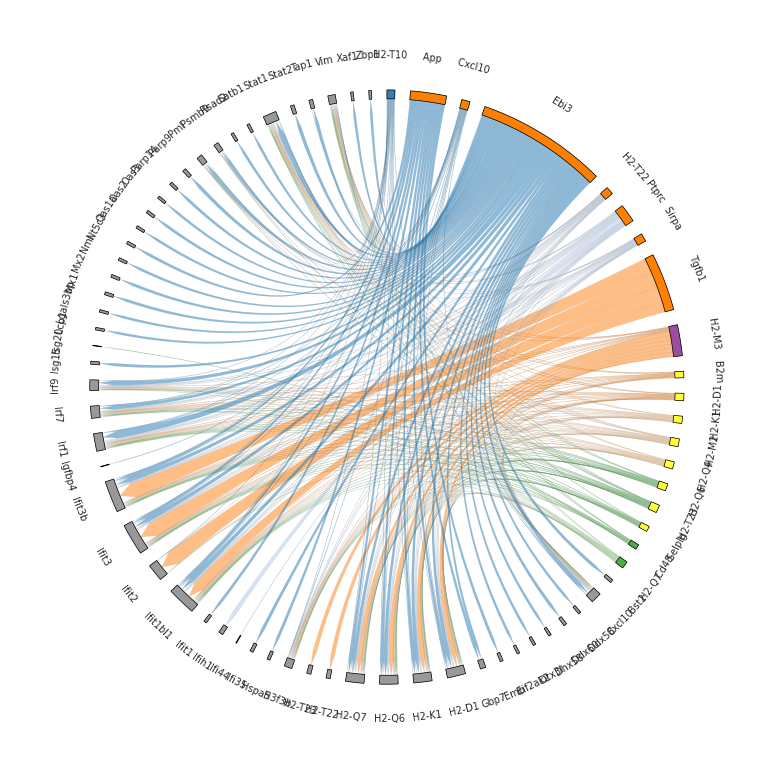

In [15]:
# Circos plot without transparency
_ = nn.make_circos_plot(vis_circos_obj, transparency=False, show=True, figsize=(7, 7))

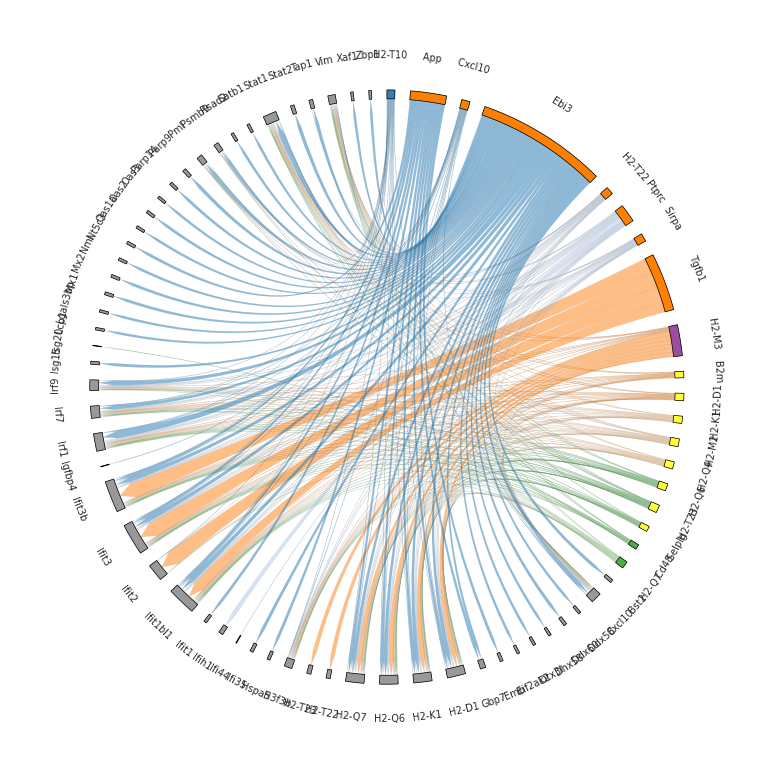

In [17]:
# Circos plot with transparency based on regulatory potential
_ = nn.make_circos_plot(vis_circos_obj, transparency=True, show=True, figsize=(7, 7))

### Visualize ligand-receptor interactions as a circos plot

We create a ligand-receptor chord diagram using the weighted ligand-receptor dataframe.

In [18]:
lr_network_top_df = nichenet_output["ligand_receptor_df"].copy()
lr_network_top_df["target_type"] = "LCMV_CD8T_receptor"
lr_network_top_df = lr_network_top_df.rename(columns={"receptor": "target"})
lr_network_top_df = lr_network_top_df.merge(ligand_type_indication_df, on="ligand")

receptor_colors = {"LCMV_CD8T_receptor": "#E41A1C"}

vis_circos_receptor_obj = nn.prepare_circos_visualization(
    lr_network_top_df,
    ligand_colors=ligand_colors,
    target_colors=receptor_colors,
)

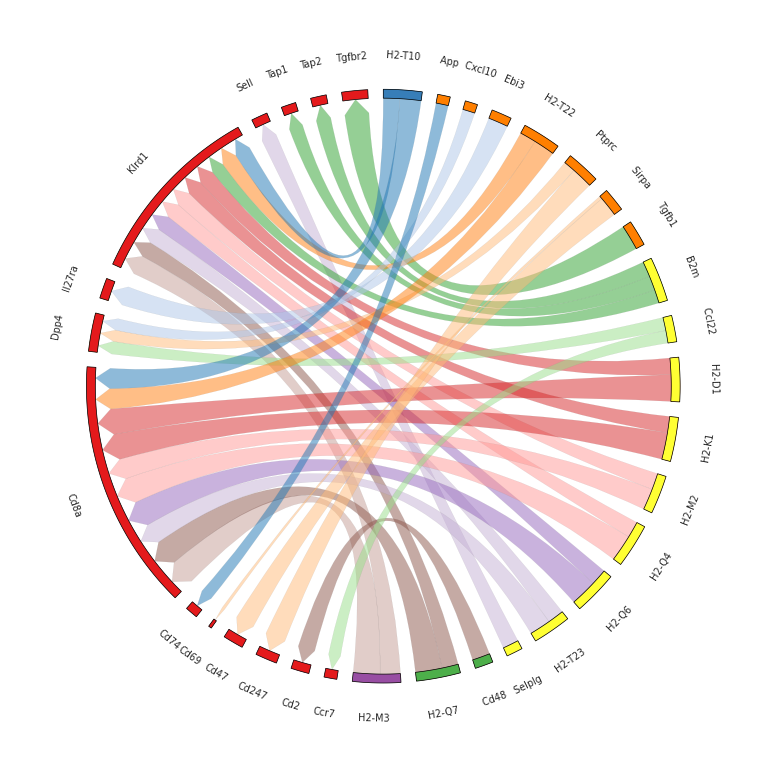

In [20]:
_ = nn.make_circos_plot(
    vis_circos_receptor_obj,
    transparency=False,
    show=True,
    figsize=(7, 7)
)